In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from matplotlib import cm  # 导入颜色映射

In [2]:
rho     = 0.75  # 设置相关系数
sigma_X = 1     # 设置 X 的标准差
sigma_Y = 2     # 设置 Y 的标准差
mu_X = 0        # 设置 X 的均值
mu_Y = 0        # 设置 Y 的均值

In [6]:
mu    = [mu_X, mu_Y]  # 定义均值向量
Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho],  # 定义协方差矩阵
        [sigma_X*sigma_Y*rho, sigma_Y**2]]

In [7]:
width = 4  # 设置绘图范围
X = np.linspace(-width, width, 321)  # 创建 X 的线性空间
Y = np.linspace(-width, width, 321)  # 创建 Y 的线性空间

In [8]:
XX, YY = np.meshgrid(X, Y)  # 创建网格数据

In [10]:
#第三个维度进行堆叠
XXYY = np.dstack((XX, YY))  # 组合 X 和 Y 的网格
bi_norm = multivariate_normal(mu, Sigma)  # 创建二维正态分布对象

In [11]:
f_X_Y_joint = bi_norm.pdf(XXYY)  # 计算联合分布的概率密度

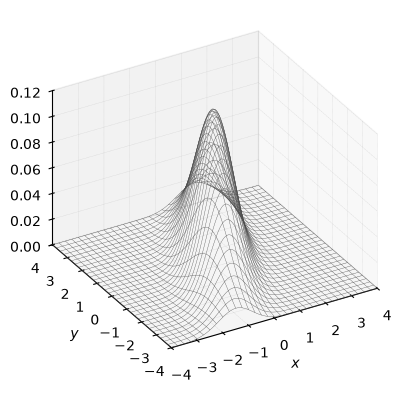

In [12]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(XX,YY, f_X_Y_joint,
                  rstride=10, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制3D网格图

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(), f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角

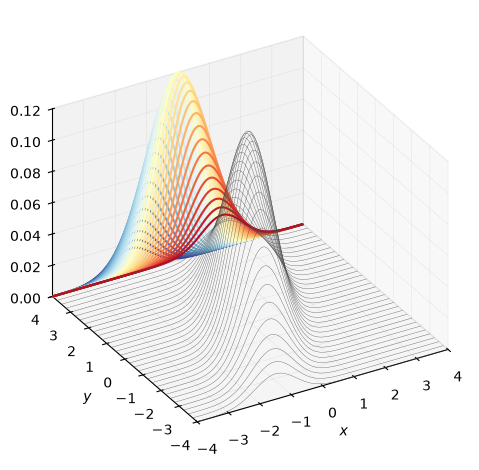

In [13]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint, rstride=10, cstride=0,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour(XX, YY, f_X_Y_joint, 
           levels = 33, zdir='y', \
            offset=XX.max(), cmap=cm.RdYlBu_r)  # 绘制投影轮廓

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(),f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

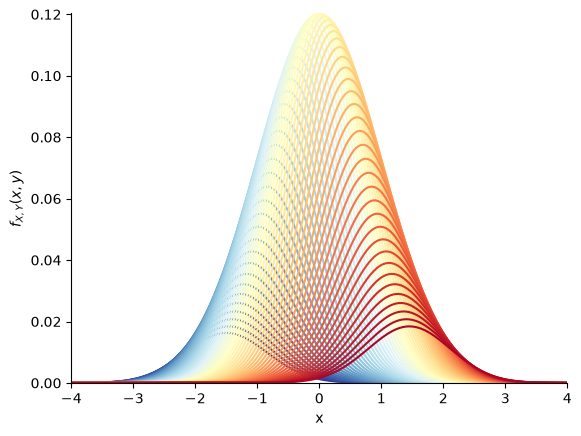

In [14]:
fig, ax = plt.subplots()  # 创建子图

colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(X)))  # 设置颜色渐变

for i in np.arange(1, len(X), 5):  # 遍历 X 的取值
    plt.plot(X, f_X_Y_joint[int(i)-1, :],
             color = colors[int(i)-1])  # 绘制条件分布

plt.xlabel('x')  # 设置 X 轴标签
plt.ylabel(r'$f_{X,Y}(x,y)$')  # 设置 Y 轴标签
ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(0, f_X_Y_joint.max())  # 设置 Y 轴范围
ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

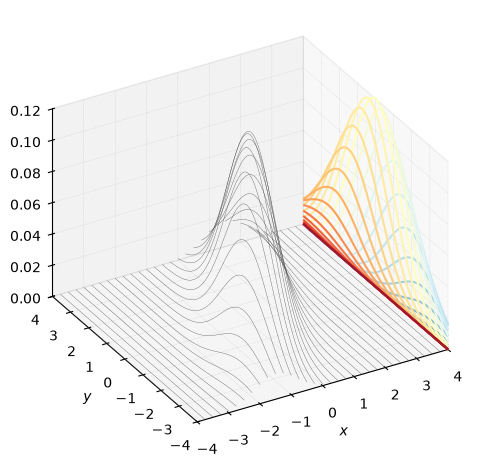

In [15]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint, rstride=0, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour(XX, YY, f_X_Y_joint, 
           levels = 33, zdir='x', \
            offset=YY.max(), cmap=cm.RdYlBu_r)  # 绘制投影轮廓

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(), f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

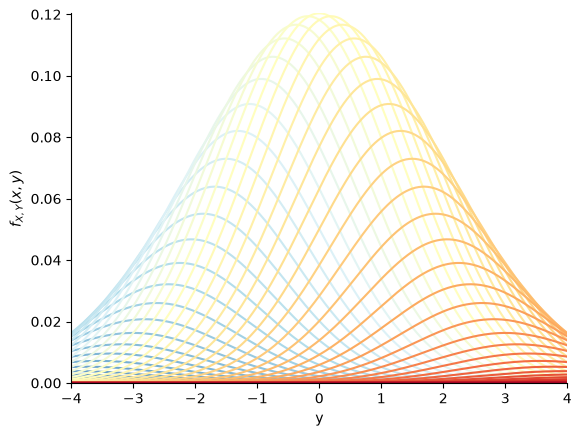

In [16]:
fig, ax = plt.subplots()  # 创建子图

colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(Y)))  # 设置颜色渐变

for i in np.arange(1, len(X), 5):  # 遍历 X 的取值
    plt.plot(X, f_X_Y_joint[:, int(i)-1],
             color = colors[int(i)-1])  # 绘制条件分布

plt.xlabel('y')  # 设置 Y 轴标签
plt.ylabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(0, f_X_Y_joint.max())  # 设置 Z 轴范围
ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

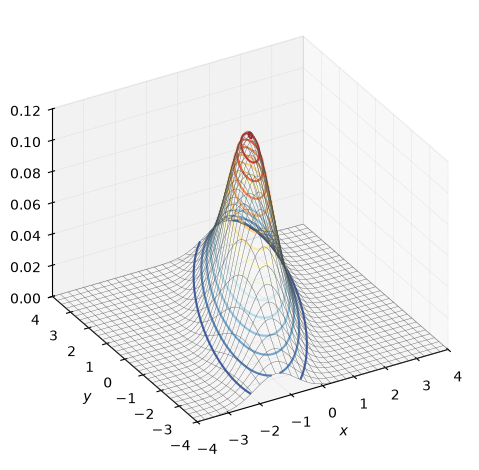

In [17]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint,
                  rstride=10, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour3D(XX,YY, f_X_Y_joint,15,
             cmap = 'RdYlBu_r')  # 绘制3D轮廓图

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.view_init(azim=-120, elev=30)  # 设置视角
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(),f_X_Y_joint.max())  # 设置 Z 轴范围
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

Text(0, 0.5, '$y$')

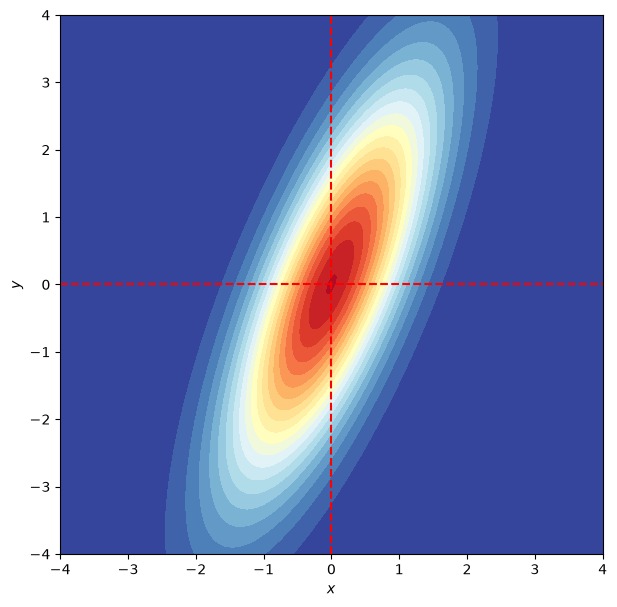

In [18]:
fig, ax = plt.subplots(figsize=(7, 7))  # 创建图形和坐标轴

plt.contourf(XX, YY, f_X_Y_joint, 20, cmap=cm.RdYlBu_r)  # 绘制填充轮廓
plt.axvline(x = mu_X, color = 'r', linestyle = '--')  # 绘制垂直参考线
plt.axhline(y = mu_Y, color = 'r', linestyle = '--')  # 绘制水平参考线

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import cm  # 导入颜色映射
from scipy.stats import multivariate_normal
from scipy.stats import norm

In [2]:
rho     = 0.75  # 设置相关系数
sigma_X = 1     # 设置 X 的标准差
sigma_Y = 1     # 设置 Y 的标准差

mu_X = 0        # 设置 X 的均值
mu_Y = 0        # 设置 Y 的均值
mu    = [mu_X, mu_Y]  # 定义均值向量

In [3]:
Sigma = [[sigma_X**2, sigma_X*sigma_Y*rho],  # 定义协方差矩阵
        [sigma_X*sigma_Y*rho, sigma_Y**2]]

In [5]:
width = 4  # 设置绘图范围
X = np.arange(-width, width, 0.05)  # 创建 X 的线性空间
Y = np.arange(-width, width, 0.05)  # 创建 Y 的线性空间

XX, YY = np.meshgrid(X, Y)  # 创建网格数据

#这里的拼接在axis = 2上,axi是= 0,1,2从外到里面,这里是元素层面维度增加了
XXYY = np.dstack((XX, YY))  # 组合 X 和 Y 的网格
bi_norm = multivariate_normal(mu, Sigma)  # 创建二维正态分布对象

In [6]:
f_X_Y_joint = bi_norm.pdf(XXYY)  # 计算联合分布的概率密度

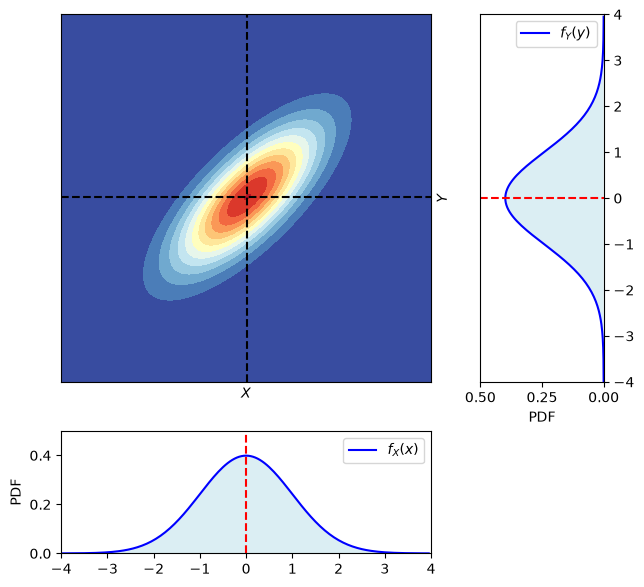

In [7]:
fig = plt.figure(figsize=(7, 7))  # 设置图形大小
gs = gridspec.GridSpec(2, 2, 
                       width_ratios=[3, 1], 
                       height_ratios=[3, 1])  # 设置网格布局

## 绘制联合分布图在左上角

ax1 = plt.subplot(gs[0])  # 创建子图1

ax1.contourf(XX, YY, f_X_Y_joint, 15, cmap=cm.RdYlBu_r)  # 绘制联合分布的等高线图
ax1.axvline(x = mu_X, color = 'k', linestyle = '--')  # 绘制 X 的均值垂直线
ax1.axhline(y = mu_Y, color = 'k', linestyle = '--')  # 绘制 Y 的均值水平线

ax1.set_xlabel('$X$')  # 设置 X 轴标签
ax1.set_ylabel('$Y$')  # 设置 Y 轴标签
ax1.yaxis.set_label_position('right')  # 设置 Y 轴标签位置
ax1.set_xticks([])  # 隐藏 X 轴刻度
ax1.set_yticks([])  # 隐藏 Y 轴刻度

## 绘制 Y 边缘分布

ax2 = plt.subplot(gs[1])  # 创建子图2
f_Y = norm.pdf(Y, loc=mu_Y, scale=sigma_Y)  # 计算 Y 的边缘分布

ax2.plot(f_Y, Y, 'b', label='$f_{Y}(y)$')  # 绘制 Y 的边缘分布曲线
ax2.axhline(y = mu_Y, color = 'r', linestyle = '--')  # 绘制 Y 的均值水平线

ax2.fill_between(f_Y,Y, 
                 edgecolor = 'none', 
                 facecolor = '#DBEEF3')  # 填充 Y 的边缘分布
ax2.legend(loc=0)  # 显示图例
ax2.set_xlabel('PDF')  # 设置 X 轴标签
ax2.set_ylim(-width, width)  # 设置 Y 轴范围
ax2.set_xlim(0, 0.5)  # 设置 X 轴范围
ax2.invert_xaxis()  # 反转 X 轴
ax2.yaxis.tick_right()  # 设置 Y 轴刻度位置

## 绘制 X 边缘分布

ax3 = plt.subplot(gs[2])  # 创建子图3
f_X = norm.pdf(X, loc=mu_X, scale=sigma_X)  # 计算 X 的边缘分布

ax3.plot(X, f_X, 'b', label='$f_{X}(x)$')  # 绘制 X 的边缘分布曲线
ax3.axvline(x = mu_X, color = 'r', linestyle = '--')  # 绘制 X 的均值垂直线

ax3.fill_between(X,f_X, 
                 edgecolor = 'none', 
                 facecolor = '#DBEEF3')  # 填充 X 的边缘分布
ax3.legend(loc=0)  # 显示图例
ax3.set_ylabel('PDF')  # 设置 Y 轴标签
ax3.yaxis.set_label_position('left')  # 设置 Y 轴标签位置
ax3.set_xlim(-width, width)  # 设置 X 轴范围
ax3.set_ylim(0, 0.5)  # 设置 Y 轴范围

## 隐藏右下角空白图

ax4 = plt.subplot(gs[3])  # 创建子图4
ax4.set_visible(False)  # 隐藏子图4


In [10]:
f_X_Y_joint = bi_norm.cdf(XXYY)  # 计算联合分布的概率密度

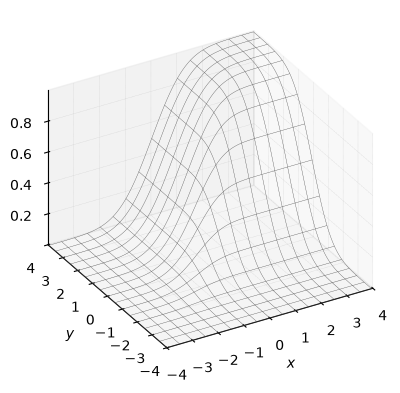

In [11]:
fig = plt.figure()
ax = plt.axes(projection='3d')

ax.plot_wireframe(XX,YY, f_X_Y_joint,
                  rstride=10, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制3D网格图

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(), f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角

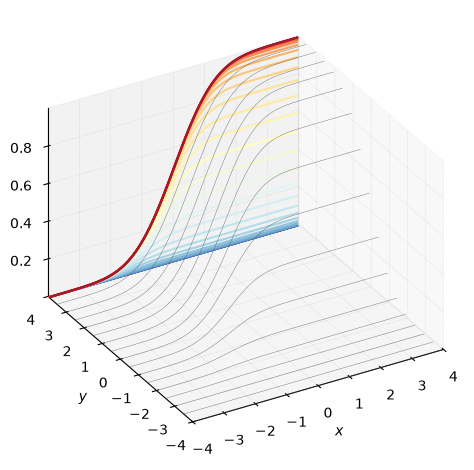

In [12]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint, rstride=10, cstride=0,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour(XX, YY, f_X_Y_joint, 
           levels = 33, zdir='y', \
            offset=XX.max(), cmap=cm.RdYlBu_r)  # 绘制投影轮廓

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(),f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

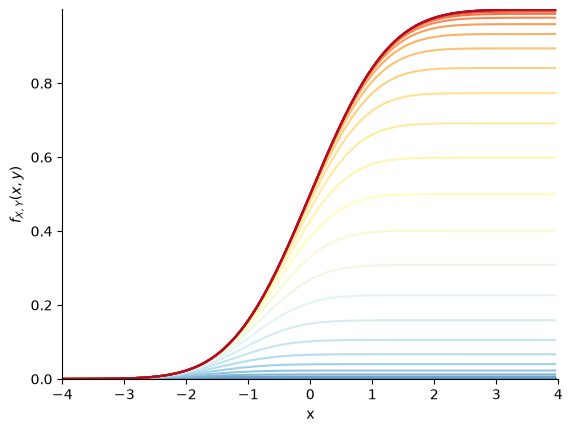

In [13]:
fig, ax = plt.subplots()  # 创建子图

colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(X)))  # 设置颜色渐变

for i in np.arange(1, len(X), 5):  # 遍历 X 的取值
    plt.plot(X, f_X_Y_joint[int(i)-1, :],
             color = colors[int(i)-1])  # 绘制条件分布

plt.xlabel('x')  # 设置 X 轴标签
plt.ylabel(r'$f_{X,Y}(x,y)$')  # 设置 Y 轴标签
ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(0, f_X_Y_joint.max())  # 设置 Y 轴范围
ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

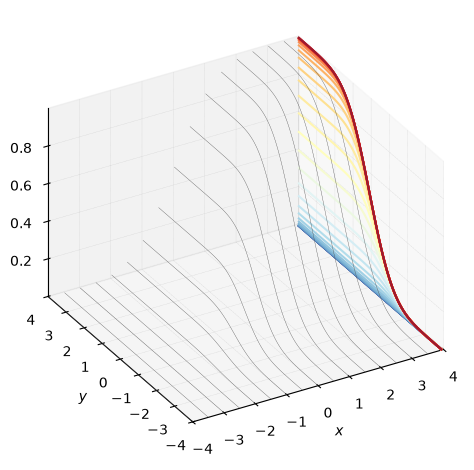

In [14]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint, rstride=0, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour(XX, YY, f_X_Y_joint, 
           levels = 33, zdir='x', \
            offset=YY.max(), cmap=cm.RdYlBu_r)  # 绘制投影轮廓

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(), f_X_Y_joint.max())  # 设置 Z 轴范围
ax.view_init(azim=-120, elev=30)  # 设置视角
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

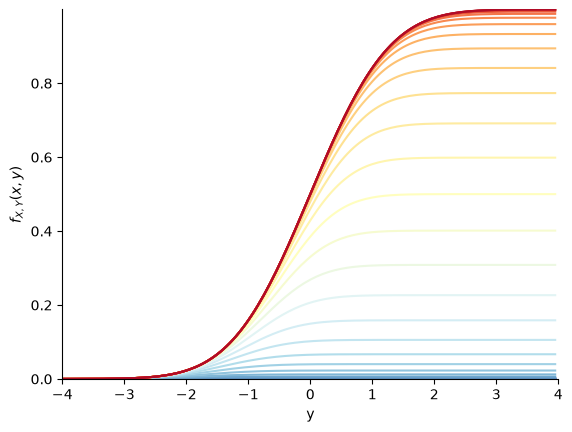

In [15]:
fig, ax = plt.subplots()  # 创建子图

colors = plt.cm.RdYlBu_r(np.linspace(0,1,len(Y)))  # 设置颜色渐变

for i in np.arange(1, len(X), 5):  # 遍历 X 的取值
    plt.plot(X, f_X_Y_joint[:, int(i)-1],
             color = colors[int(i)-1])  # 绘制条件分布

plt.xlabel('y')  # 设置 Y 轴标签
plt.ylabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(0, f_X_Y_joint.max())  # 设置 Z 轴范围
ax.spines['top'].set_visible(False)  # 隐藏上边框
ax.spines['right'].set_visible(False)  # 隐藏右边框

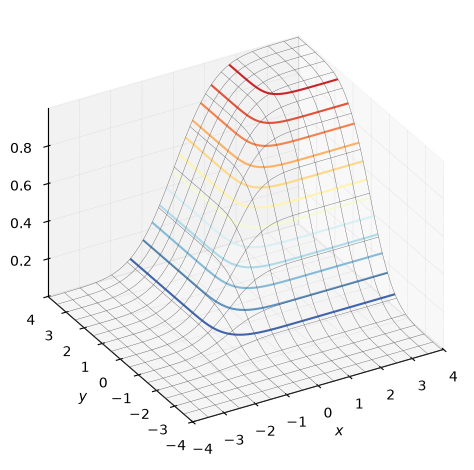

In [16]:
fig = plt.figure()
ax = plt.axes(projection='3d')  # 创建3D子图

ax.plot_wireframe(XX, YY, f_X_Y_joint,
                  rstride=10, cstride=10,
                  color = [0.3,0.3,0.3],
                  linewidth = 0.25)  # 绘制网格图

ax.contour3D(XX,YY, f_X_Y_joint,15,
             cmap = 'RdYlBu_r')  # 绘制3D轮廓图

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签
ax.set_zlabel(r'$f_{X,Y}(x,y)$')  # 设置 Z 轴标签
ax.view_init(azim=-120, elev=30)  # 设置视角
ax.set_proj_type('ortho')  # 设置正交投影
ax.xaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 X 轴网格
ax.yaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Y 轴网格
ax.zaxis._axinfo["grid"].update({"linewidth":0.25, "linestyle" : ":"})  # 调整 Z 轴网格

ax.set_xlim(-width, width)  # 设置 X 轴范围
ax.set_ylim(-width, width)  # 设置 Y 轴范围
ax.set_zlim(f_X_Y_joint.min(),f_X_Y_joint.max())  # 设置 Z 轴范围
plt.tight_layout()  # 调整布局
plt.show()  # 显示图形

Text(0, 0.5, '$y$')

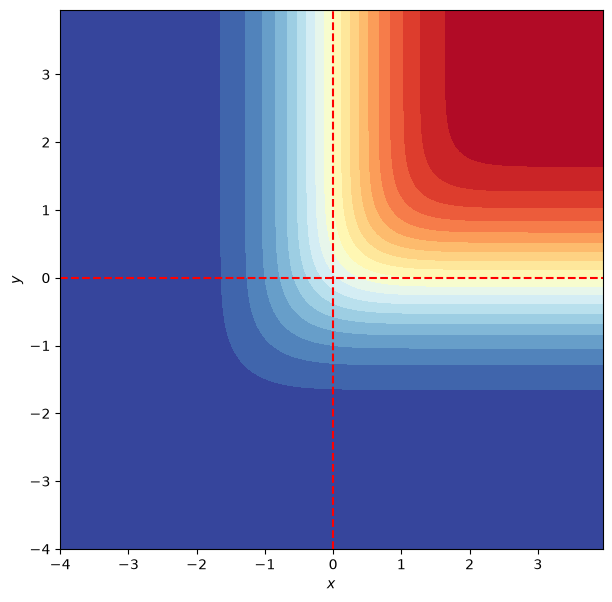

In [17]:
fig, ax = plt.subplots(figsize=(7, 7))  # 创建图形和坐标轴

plt.contourf(XX, YY, f_X_Y_joint, 20, cmap=cm.RdYlBu_r)  # 绘制填充轮廓
plt.axvline(x = mu_X, color = 'r', linestyle = '--')  # 绘制垂直参考线
plt.axhline(y = mu_Y, color = 'r', linestyle = '--')  # 绘制水平参考线

ax.set_xlabel(r'$x$')  # 设置 X 轴标签
ax.set_ylabel(r'$y$')  # 设置 Y 轴标签

In [20]:
import matplotlib.pyplot as plt
import numpy as np
#从二维基本几何形状里面导入一个长方体
from matplotlib.patches import Rectangle

In [21]:
x = np.linspace(-4,4,num = 201)  # 创建 x 的线性空间
y = np.linspace(-4,4,num = 201)  # 创建 y 的线性空间
sigma_X = 1  # 设置 X 的标准差
sigma_Y = 2  # 设置 Y 的标准差

In [22]:
xx,yy = np.meshgrid(x,y)  # 创建网格数据

kk = np.linspace(-0.8,0.8,num = 9)  # 生成不同的相关系数值

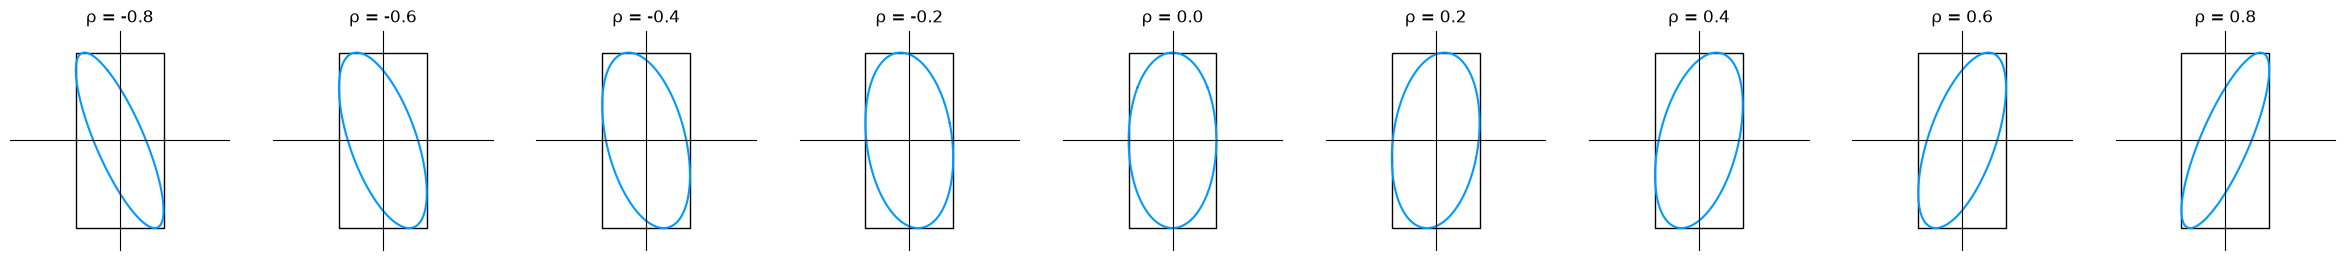

In [23]:
fig = plt.figure(figsize=(30,5))  # 设置图形尺寸

for i in range(0,len(kk)):
    
    k = kk[i]  # 当前的相关系数值
    ax = fig.add_subplot(1,len(kk),int(i+1))  # 创建子图
    ellipse = ((xx/sigma_X)**2 - 2*k*(xx/sigma_X)*(yy/sigma_Y) + (yy/sigma_Y)**2)/(1 - k**2)  # 计算椭圆轮廓
    
    plt.contour(xx,yy,ellipse,levels = [1], colors = '#0099FF')  # 绘制椭圆轮廓线

    #xy是起点的意思.width和height是正方向的延伸
    rect = Rectangle(xy = [- sigma_X, - sigma_Y] , 
                     width = 2*sigma_X, 
                     height = 2*sigma_Y,
                     edgecolor = 'k',facecolor="none")  # 创建矩形边界框
    
    ax.add_patch(rect)  # 添加矩形到子图中

    ax.set_xlim([-2.5,2.5])  # 设置 X 轴范围
    ax.set_ylim([-2.5,2.5])  # 设置 Y 轴范围
    ax.set_xticks([])  # 隐藏 X 轴刻度
    ax.set_yticks([])  # 隐藏 Y 轴刻度
    ax.spines['left'].set_position('zero')  # 设置左侧轴位置
    ax.spines['right'].set_color('none')  # 隐藏右侧轴
    ax.spines['top'].set_position('zero')  # 设置上侧轴位置
    ax.spines['bottom'].set_color('none')  # 隐藏下侧轴
    plt.gca().set_aspect('equal', adjustable='box')  # 设置图形比例
    ax.set_title('\u03C1 = %0.1f' %k)  # 设置标题

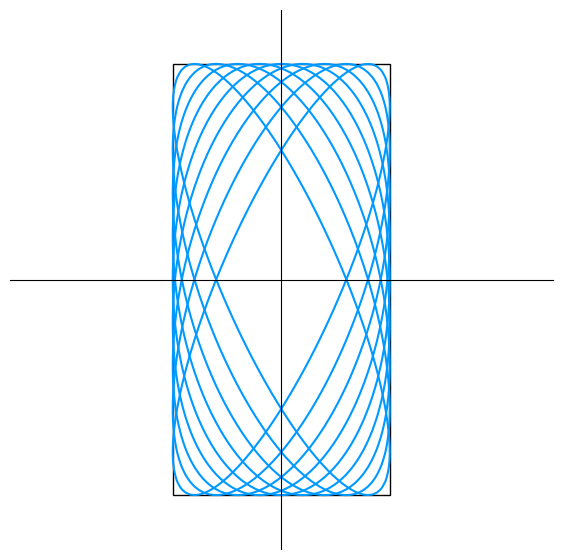

In [24]:
fig, ax = plt.subplots(figsize=(7, 7))  # 创建图形和坐标轴

for i in range(0, len(kk)):
    
    k = kk[i]  # 当前的相关系数值
    ellipse = ((xx/sigma_X)**2 - 2*k*(xx/sigma_X)*(yy/sigma_Y) + (yy/sigma_Y)**2)/(1 - k**2)  # 计算椭圆轮廓
    
    plt.contour(xx, yy, ellipse, levels = [1], colors = '#0099FF')  # 绘制椭圆轮廓线

rect = Rectangle(xy = [- sigma_X, - sigma_Y] , 
                 width = 2*sigma_X, 
                 height = 2*sigma_Y,
                 edgecolor = 'k', facecolor="none")  # 创建矩形边界框
ax.add_patch(rect)  # 添加矩形到图形中

ax.set_xlim([-2.5,2.5])  # 设置 X 轴范围
ax.set_ylim([-2.5,2.5])  # 设置 Y 轴范围
ax.set_xticks([])  # 隐藏 X 轴刻度
ax.set_yticks([])  # 隐藏 Y 轴刻度
ax.spines['left'].set_position('zero')  # 设置左侧轴位置
ax.spines['right'].set_color('none')  # 隐藏右侧轴
ax.spines['top'].set_position('zero')  # 设置上侧轴位置
ax.spines['bottom'].set_color('none')  # 隐藏下侧轴

In [25]:
import matplotlib.pyplot as plt
from numpy.random import multivariate_normal as multi_norm
import numpy as np
from matplotlib.patches import Rectangle

In [26]:
np.random.seed(2)  # 设置随机种子

rho = -0.9  # 设置相关系数

mu_X = 0  # 设置 X 的均值
mu_Y = 0  # 设置 Y 的均值

MU = [mu_X, mu_Y]  # 定义均值向量

sigma_X = 1  # 设置 X 的标准差
sigma_Y = 1  # 设置 Y 的标准差

In [27]:
SIGMA = [[sigma_X**2, sigma_X*sigma_Y*rho], 
         [sigma_X*sigma_Y*rho, sigma_Y**2]]  # 定义协方差矩阵

num = 500  # 样本数

X, Y = multi_norm(MU, SIGMA, num).T  # 生成二维正态分布数据

center_X = np.mean(X)  # 计算 X 的均值
center_Y = np.mean(Y)  # 计算 Y 的均值

[]

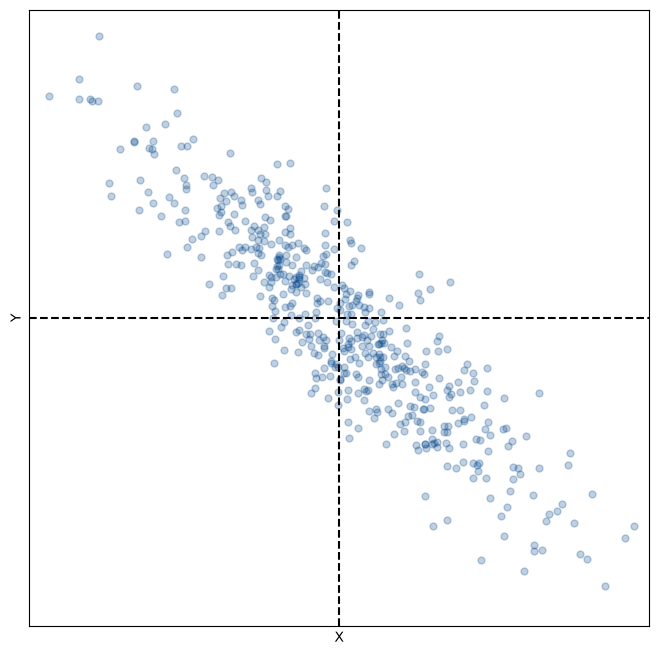

In [28]:
fig, ax = plt.subplots(figsize=(8, 8))  # 创建图形和坐标轴

plt.plot(X, Y, '.', color = '#00448A', 
         alpha = 0.25, markersize = 10)  # 绘制散点

ax.axvline(x = 0, color = 'k', linestyle = '--')  # 绘制垂直参考线
ax.axhline(y = 0, color = 'k', linestyle = '--')  # 绘制水平参考线

ax.set_xlabel('X')  # 设置 X 轴标签
ax.set_ylabel('Y')  # 设置 Y 轴标签
ax.set_xlim((-3, 3))  # 设置 X 轴范围
ax.set_ylim((-3, 3))  # 设置 Y 轴范围
ax.xaxis.set_ticks([])  # 隐藏 X 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 Y 轴刻度

In [29]:
from scipy.stats import multivariate_normal

X_grid = np.linspace(-3, 3, 200)  # 创建 X 网格
Y_grid = np.linspace(-3, 3, 200)  # 创建 Y 网格

In [30]:
XX, YY = np.meshgrid(X_grid, Y_grid)  # 创建网格数据

XXYY = np.dstack((XX, YY))  # 组合 X 和 Y 的网格
bi_norm = multivariate_normal(MU, SIGMA)  # 创建二维正态分布对象

In [31]:
pdf_fine = bi_norm.pdf(XXYY)  # 计算联合分布的概率密度

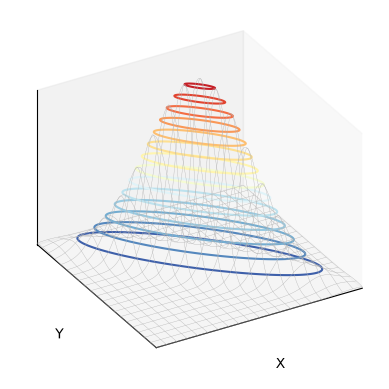

In [32]:
fig = plt.figure()  # 创建图形
ax = plt.axes(projection='3d')  # 设置3D投影

ax.plot_wireframe(XX, YY, pdf_fine,
                  cstride = 10, rstride = 10,
                  color = [0.7, 0.7, 0.7],
                  linewidth = 0.25)  # 绘制3D网格图

ax.contour3D(XX, YY, pdf_fine, 15,
             cmap = 'RdYlBu_r')  # 绘制3D等高线图

ax.set_proj_type('ortho')  # 设置正交投影
ax.view_init(azim=-120, elev=30)  # 设置视角
ax.xaxis.set_ticks([])  # 隐藏 X 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 Y 轴刻度
ax.zaxis.set_ticks([])  # 隐藏 Z 轴刻度
ax.set_xlabel('X')  # 设置 X 轴标签
ax.set_ylabel('Y')  # 设置 Y 轴标签
ax.set_zlabel('PDF')  # 设置 Z 轴标签
# ax.w_xaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # 设置 X 轴背景色
# ax.w_yaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # 设置 Y 轴背景色
# ax.w_zaxis.set_pane_color((1.0, 1.0, 1.0, 1.0))  # 设置 Z 轴背景色
ax.set_xlim3d([-3, 3])  # 设置 X 轴范围
ax.set_ylim3d([-3, 3])  # 设置 Y 轴范围
ax.set_zlim3d([0, 0.3])  # 设置 Z 轴范围

plt.show()  # 显示图形

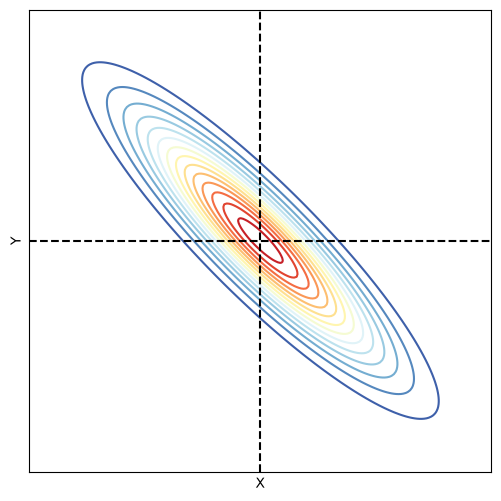

In [33]:
fig, ax = plt.subplots(figsize=(6, 6))  # 创建图形和坐标轴

ax.contour(XX, YY, pdf_fine, 15,
           cmap = 'RdYlBu_r')  # 绘制2D等高线图
ax.axvline(x = 0, color = 'k', linestyle = '--')  # 绘制垂直参考线
ax.axhline(y = 0, color = 'k', linestyle = '--')  # 绘制水平参考线
ax.xaxis.set_ticks([])  # 隐藏 X 轴刻度
ax.yaxis.set_ticks([])  # 隐藏 Y 轴刻度
ax.set_aspect('equal')  # 设置图形比例
ax.set_xlabel('X')  # 设置 X 轴标签
ax.set_ylabel('Y')  # 设置 Y 轴标签
plt.show()  # 显示图形

In [34]:
def draw_vector(vector, RBG):  # 自定义函数：绘制向量
    array = np.array([[0, 0, vector[0], vector[1]]])
    X, Y, U, V = zip(*array)
    plt.quiver(X, Y, U, V, angles='xy', scale_units='xy', scale=1, color=RBG)  # 绘制箭头向量

In [37]:
#输入相关性系数,反余弦函数求出角度
theta = np.arccos(rho)  # 计算角度 theta

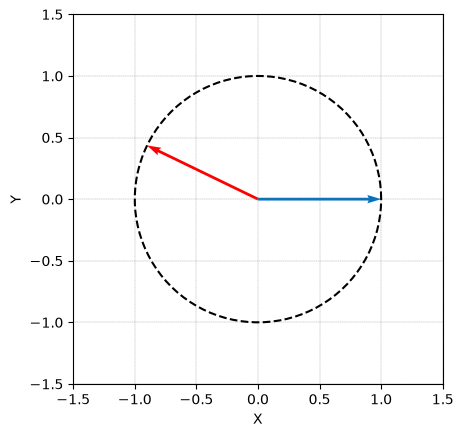

In [38]:
fig, ax = plt.subplots()  # 创建图形和坐标轴

draw_vector([1, 0], np.array([0, 112, 192])/255)  # 绘制 X 轴向量
draw_vector([np.cos(theta), np.sin(theta)], np.array([255, 0, 0])/255)  # 绘制角度向量

circle_theta = np.linspace(0, 2*np.pi, 100)  # 创建角度数据

circle_X = np.cos(circle_theta)  # 计算圆的 X 坐标
circle_Y = np.sin(circle_theta)  # 计算圆的 Y 坐标

ax.plot(circle_X, circle_Y, color = 'k', linestyle = '--')  # 绘制单位圆

ax.set_xlabel('X')  # 设置 X 轴标签
ax.set_ylabel('Y')  # 设置 Y 轴标签
plt.axis('scaled')  # 设置图形比例
ax.set_xlim([-1.5, 1.5])  # 设置 X 轴范围
ax.set_ylim([-1.5, 1.5])  # 设置 Y 轴范围
ax.grid(linestyle='--', linewidth=0.25, color=[0.5, 0.5, 0.5])  # 设置网格
plt.show()  # 显示图形
